# Single Atom Calculation

In [1]:
# Uncomment the next line if you have ipympl installed and want interactive plots
# %matplotlib widget

import matplotlib.pyplot as plt
import numpy as np

import pairinteraction.real as pi
from pairinteraction.visualization.colormaps import alphamagma

## State of Interest

In [2]:
ket = pi.KetAtom("Rb", n=60, l=0, j=0.5, m=0.5)
ket_energy = ket.get_energy("GHz")
print(f"State of interest: {ket}")

State of interest: |Rb:60,S_1/2,1/2⟩


## Basis

In [3]:
basis = pi.BasisAtom(ket.species, n=(58, 62), l=(-2, 2))
print(str(basis))
print(f" ⇒ Basis consists of {basis.number_of_kets} kets")

BasisAtomReal(n=(58, 62), l=(-2, 2))
 ⇒ Basis consists of 90 kets


## System

In [4]:
steps = 50
efield_x = np.linspace(0.0, 0.0, steps)
efield_y = np.linspace(0.0, 0.0, steps)
efield_z = np.linspace(0.0, 10.0, steps)
bfield_x = np.linspace(0.0, 0.0, steps)
bfield_y = np.linspace(0.0, 0.0, steps)
bfield_z = np.linspace(0.0, 0.0, steps)

In [5]:
systems = []
for i in range(steps):
    system = pi.SystemAtom(basis)
    system.set_electric_field([efield_x[i], efield_y[i], efield_z[i]], unit="V/cm")
    system.set_magnetic_field([bfield_x[i], bfield_y[i], bfield_z[i]], unit="G")
    system.set_diamagnetism_enabled(True)
    systems.append(system)

pi.diagonalize(systems, diagonalizer="lapacke_evr", float_type="float32")

In [6]:
energies_list = [system.get_eigenenergies(unit="GHz") - ket.get_energy("GHz") for system in systems]
overlaps_list = [system.get_eigenbasis().get_overlaps(ket) for system in systems]

## Plot

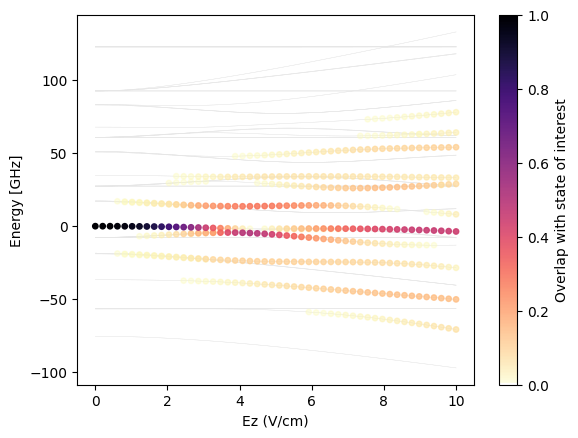

In [7]:
fig, ax = plt.subplots()

ax.set_xlabel(r"Ez (V/cm)")
ax.set_ylabel("Energy [GHz]")

if len({len(es) for es in energies_list}) <= 1:  # check if homogeneous shape
    ax.plot(efield_z, np.array(energies_list), c="0.9", lw=0.25, zorder=-10)
else:
    for x, es in zip(efield_z, energies_list):
        ax.plot([x] * len(es), es, c="0.9", ls="None", marker=".", zorder=-10)

x_repeated = np.hstack([val * np.ones_like(es) for val, es in zip(efield_z, energies_list)])
energies_flattened = np.hstack(energies_list)
overlaps_flattened = np.hstack(overlaps_list)
sorter = np.argsort(overlaps_flattened)

scat = ax.scatter(
    x_repeated[sorter],
    energies_flattened[sorter],
    c=overlaps_flattened[sorter],
    s=15,
    vmin=0,
    vmax=1,
    cmap=alphamagma
)

fig.colorbar(scat, ax=ax, label="Overlap with state of interest")

plt.show()